# Graph Playground

Self-contained notebook for experimenting with the LangGraph structure.
Every piece — state, nodes, edges — is defined here. No imports from `chatbot.api.*`.

**Workflow for editing:**
1. Edit a node function in **Section 3**
2. Edit the graph wiring in **Section 4**
3. Re-run **Section 4** to recompile
4. Run **Section 5** to test

Sections 1–3 only need to be re-run if you change a node or the state shape.

---
## Section 1 — Imports & Config

In [1]:
import asyncio
import json
import os
import sys
from itertools import tee

from dotenv import find_dotenv, load_dotenv

PROJECT_ROOT = os.path.abspath(".")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

load_dotenv(find_dotenv(".env.dev"))
print("Project root:", PROJECT_ROOT)

Project root: /home/eeshan/Documents/IMDB


In [2]:
# ── LangChain / LangGraph ──────────────────────────────────────────────────────
# ── Standard lib ──────────────────────────────────────────────────────────────
from typing import Annotated

from langchain_anthropic import ChatAnthropic
from langchain_core.language_models import BaseChatModel
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, SystemMessage
from langchain_core.runnables import RunnableConfig
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, StateGraph
from langgraph.graph.message import add_messages
from sqlalchemy import text
from typing_extensions import TypedDict

# ── DB (only allowed external import) ─────────────────────────────────────────
from db.postgres_session import engine

print("Imports OK")

Imports OK


In [3]:
# ── Provider / model ──────────────────────────────────────────────────────────
# Change these to switch between providers without touching any node code.

PROVIDER = os.getenv("LLM_PROVIDER", "openai")  # "openai" | "anthropic"
MODEL = os.getenv("LLM_MODEL", "gpt-4o")  # e.g. "gpt-4o-mini", "claude-sonnet-4-6"

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "")
ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY", "")

print(f"Provider: {PROVIDER}  Model: {MODEL}")


def get_llm(provider: str = PROVIDER, model: str = MODEL) -> BaseChatModel:
    if provider == "openai":
        return ChatOpenAI(model=model, api_key=OPENAI_API_KEY, streaming=True)
    if provider == "anthropic":
        return ChatAnthropic(model=model, api_key=ANTHROPIC_API_KEY, streaming=True)
    raise ValueError(f"Unknown provider: {provider!r}")

Provider: openai  Model: gpt-4o-mini


---
## Section 2 — State & Shared Utilities

Edit `ChatState` here to add or remove fields as you change the graph.

In [4]:
# ── State ─────────────────────────────────────────────────────────────────────
# Add new fields here when a new node needs to pass data downstream.


class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    greeted_user: bool
    sql_query: str
    sql_results: str
    # ── add new fields below ──
    # sql_valid:   bool     # example: output of a sql_validator node
    # intent:      str      # example: output of an intent classifier


print("State fields:", list(ChatState.__annotations__.keys()))

State fields: ['messages', 'greeted_user', 'sql_query', 'sql_results']


In [5]:
# ── DB utility ────────────────────────────────────────────────────────────────
# Used by run_sql and any node that needs to query Postgres directly.

_MAX_ROWS = 100


def execute_sql(query: str) -> str:
    try:
        with engine.connect() as conn:
            result = conn.execute(text(query))
            rows = result.fetchmany(_MAX_ROWS)
            if not rows:
                return "Query returned no results."
            cols = list(result.keys())
            header = " | ".join(cols)
            lines = [header, "-" * len(header)]
            for row in rows:
                lines.append(" | ".join("NULL" if v is None else str(v) for v in row))
            if len(rows) == _MAX_ROWS:
                lines.append(f"... (capped at {_MAX_ROWS} rows)")
            return "\n".join(lines)
    except Exception as exc:
        return f"SQL Error: {exc}"


# Quick smoke test
print(execute_sql("SELECT current_database()"))

current_database
----------------
ingestion_db


---
## Section 3 — Node Definitions

Each node is an `async def` that takes `(state: ChatState, config: RunnableConfig)` and returns a `dict` with the keys it wants to update.

**To add a node:** define a new function here, then wire it in Section 4.  
**To remove a node:** comment out its `add_node` and edge lines in Section 4 — the function can stay here.

Active nodes in the default graph:
```
greeting ──(conditional)──► generate_sql ──► run_sql ──► generate_answer ──► END
              └──────────────────────────────────────────────────────────────► END  (if greeting)
```

In [6]:
# ── System prompts ────────────────────────────────────────────────────────────
# Edit these to tune node behaviour without touching the node logic.

SCHEMA = """
Table: title_basics
  tconst VARCHAR PK, title_type VARCHAR, primary_title TEXT, original_title TEXT,
  is_adult BOOLEAN, start_year INT, end_year INT, runtime_minutes INT, genres TEXT[]

Table: title_ratings
  tconst VARCHAR FK→title_basics, average_rating FLOAT, num_votes INT

Table: title_akas
  title_id VARCHAR FK→title_basics, ordering INT, title TEXT, region VARCHAR,
  country_name VARCHAR, language VARCHAR, types TEXT[], attributes TEXT[], is_original_title BOOLEAN

Table: title_crew
  tconst VARCHAR FK→title_basics, directors TEXT[], writers TEXT[]

Table: title_episode
  tconst VARCHAR FK→title_basics, parent_tconst VARCHAR, season_number INT, episode_number INT

Table: title_principals
  tconst VARCHAR FK→title_basics, ordering INT, nconst VARCHAR FK→name_basics,
  category VARCHAR, job TEXT, characters TEXT

Table: name_basics
  nconst VARCHAR PK, primary_name TEXT, birth_year INT, death_year INT,
  primary_profession TEXT[], known_for_titles TEXT[]

Tips: use 'Drama' = ANY(genres) for arrays; always JOIN title_ratings for rating queries.
"""

SQL_SYSTEM = f"""You are a PostgreSQL expert. Write a single valid SQL query that answers the user's question.

Schema:
{SCHEMA}

Rules:
- Output ONLY the raw SQL — no markdown fences, no explanation.
- Use lowercase identifiers.
- Default LIMIT 20 unless asked for more.
- Use ANY() for array columns.
"""

ANSWER_SYSTEM = """You are a helpful assistant answering questions about IMDB data.
A SQL query has already been run. Use the results to give a concise, clear answer.
If results are empty or show an error, say so honestly — never invent data."""

GREETING_SYSTEM = """You are a message classifier.
Decide if the user's message is a greeting (primary intent: greet or start a conversation).
Return ONLY valid JSON — no markdown fences:
{"is_greeting": true | false, "response": "<friendly reply if greeting, else null>"}"""

print("System prompts loaded.")

System prompts loaded.


In [7]:
# ── Helper ────────────────────────────────────────────────────────────────────
def _clean_sql(raw: str) -> str:
    sql = raw.strip()
    for fence in (
        "```sql\n",
        "```postgresql\n",
        "```\n",
        "```sql",
        "```postgresql",
        "```",
    ):
        if sql.startswith(fence):
            sql = sql[len(fence) :]
            break
    return sql.rstrip("`").strip()


def _cfg(config: RunnableConfig) -> dict:
    return config.get("configurable", {})

In [8]:
# ── NODE: greeting ────────────────────────────────────────────────────────────
# Classifies the last user message.
# Returns the greeting reply + sets greeted_user=True, OR returns {} to continue.


async def node_greeting(state: ChatState, config: RunnableConfig) -> dict:
    cfg = _cfg(config)
    llm = get_llm(cfg.get("provider", PROVIDER), cfg.get("model", MODEL))

    last = state["messages"][-1].content if state["messages"] else ""
    resp = await llm.ainvoke(
        [
            SystemMessage(content=GREETING_SYSTEM),
            HumanMessage(content=last),
        ]
    )

    raw = resp.content.strip()
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[-1].rsplit("```", 1)[0].strip()
    try:
        parsed = json.loads(raw)
    except json.JSONDecodeError:
        return {}  # parse failure → treat as non-greeting, fall through

    if parsed.get("is_greeting") and parsed.get("response"):
        return {
            "messages": [AIMessage(content=parsed["response"])],
            "greeted_user": True,
        }
    return {}

In [9]:
# ── NODE: generate_sql ────────────────────────────────────────────────────────
# Converts the conversation into a single SQL query.


async def node_generate_sql(state: ChatState, config: RunnableConfig) -> dict:
    cfg = _cfg(config)
    llm = get_llm(cfg.get("provider", PROVIDER), cfg.get("model", MODEL))

    messages = [SystemMessage(content=SQL_SYSTEM), *state["messages"]]
    resp = await llm.ainvoke(messages)
    return {"sql_query": _clean_sql(resp.content)}

In [10]:
# ── NODE: run_sql ─────────────────────────────────────────────────────────────
# Executes the SQL from state["sql_query"] against Postgres.


async def node_run_sql(state: ChatState, config: RunnableConfig) -> dict:
    results = await asyncio.to_thread(execute_sql, state["sql_query"])
    return {"sql_results": results}

In [11]:
# ── NODE: generate_answer ─────────────────────────────────────────────────────
# Produces a natural-language answer from the SQL results.


async def node_generate_answer(state: ChatState, config: RunnableConfig) -> dict:
    cfg = _cfg(config)
    llm = get_llm(cfg.get("provider", PROVIDER), cfg.get("model", MODEL))

    context = f"SQL executed:\n{state['sql_query']}\n\nResults:\n{state['sql_results']}"
    messages = [
        SystemMessage(content=ANSWER_SYSTEM),
        *state["messages"],
        HumanMessage(content=f"[Database context]\n{context}"),
    ]
    resp = await llm.ainvoke(messages)
    return {"messages": [AIMessage(content=resp.content)]}

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# SCRATCH AREA — define new experimental nodes here before wiring them in
# ══════════════════════════════════════════════════════════════════════════════

# Example: a node that validates SQL before running it
# async def node_validate_sql(state: ChatState, config: RunnableConfig) -> dict:
#     query = state["sql_query"]
#     # Simple heuristic: reject if no SELECT or if it contains DDL keywords
#     forbidden = ("drop ", "delete ", "truncate ", "insert ", "update ", "alter ")
#     if not query.lower().startswith("select") or any(kw in query.lower() for kw in forbidden):
#         return {"sql_results": "SQL Error: query rejected by validator.", "sql_query": ""}
#     return {}  # pass through unchanged


# Example: a node that summarises long sql_results before passing to generate_answer
# async def node_summarise_results(state: ChatState, config: RunnableConfig) -> dict:
#     results = state["sql_results"]
#     if len(results) < 1000:
#         return {}  # short enough, skip
#     cfg = _cfg(config)
#     llm = get_llm(cfg.get("provider", PROVIDER), cfg.get("model", MODEL))
#     resp = await llm.ainvoke([HumanMessage(content=f"Summarise these DB results in under 200 words:\n{results}")])
#     return {"sql_results": resp.content}


print("Scratch area ready.")

Scratch area ready.


---
## Section 4 — Graph Assembly

This is the only cell you need to re-run after changing nodes or edges.
The graph is compiled into `graph` and a fresh `MemorySaver` is created.

In [13]:
# ── Routing function ──────────────────────────────────────────────────────────
# Called after node_greeting. Returns the name of the next node.
# Edit this to change how greetings are routed.


def route_from_greeting(state: ChatState) -> str:
    # If the last message is an AIMessage, the greeting node replied → done.
    if state["messages"] and isinstance(state["messages"][-1], AIMessage):
        return END
    return "generate_sql"


# ── Build ─────────────────────────────────────────────────────────────────────
def build_graph() -> tuple:
    """Returns (compiled_graph, checkpointer). Call this to rebuild after edits."""
    checkpointer = MemorySaver()
    g = StateGraph(ChatState)

    # ── Add nodes ─────────────────────────────────────────────────────────────
    # Comment out a line to remove the node from the graph.
    g.add_node("greeting", node_greeting)
    g.add_node("generate_sql", node_generate_sql)
    g.add_node("run_sql", node_run_sql)
    g.add_node("generate_answer", node_generate_answer)
    # g.add_node("validate_sql",   node_validate_sql)     # ← uncomment to add
    # g.add_node("summarise",      node_summarise_results) # ← uncomment to add

    # ── Entry point ───────────────────────────────────────────────────────────
    g.set_entry_point("greeting")

    # ── Edges ─────────────────────────────────────────────────────────────────
    # Conditional edge from greeting
    g.add_conditional_edges(
        "greeting",
        route_from_greeting,
        {END: END, "generate_sql": "generate_sql"},
    )

    # Linear chain for SQL path
    g.add_edge("generate_sql", "run_sql")
    # g.add_edge("generate_sql",  "validate_sql")   # ← swap these two lines to insert validator
    # g.add_edge("validate_sql",  "run_sql")
    g.add_edge("run_sql", "generate_answer")
    # g.add_edge("run_sql",       "summarise")       # ← swap these two to insert summariser
    # g.add_edge("summarise",     "generate_answer")
    g.add_edge("generate_answer", END)

    return g.compile(checkpointer=checkpointer), checkpointer


graph, _cp = build_graph()
print("Graph compiled.")
print("Nodes:", list(graph.get_graph().nodes.keys()))

Graph compiled.
Nodes: ['__start__', 'greeting', 'generate_sql', 'run_sql', 'generate_answer', '__end__']


In [14]:
# Visualise the current graph
from IPython.display import Markdown, display

mermaid_src = graph.get_graph().draw_mermaid()
display(Markdown(f"```mermaid\n{mermaid_src}\n```"))

```mermaid
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	greeting(greeting)
	generate_sql(generate_sql)
	run_sql(run_sql)
	generate_answer(generate_answer)
	__end__([<p>__end__</p>]):::last
	__start__ --> greeting;
	generate_sql --> run_sql;
	greeting -.-> __end__;
	greeting -.-> generate_sql;
	run_sql --> generate_answer;
	generate_answer --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

```

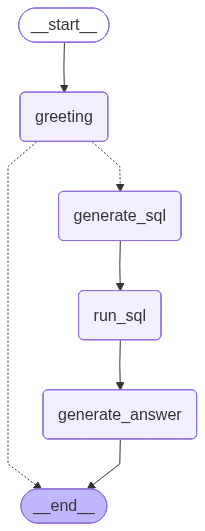

In [15]:
# PNG render (requires pygraphviz or pillow+cairosvg)
try:
    from IPython.display import Image

    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"PNG unavailable ({e}). Mermaid diagram above is the fallback.")

---
## Section 5 — Run & Inspect

Helpers for invoking the graph, streaming events, and inspecting state.

In [16]:
import uuid

# Create a fresh thread for this session. Re-run this cell to reset history.
THREAD_ID = str(uuid.uuid4())


def make_config(
    thread_id: str = THREAD_ID, provider: str = PROVIDER, model: str = MODEL
) -> dict:
    return {
        "configurable": {"thread_id": thread_id, "provider": provider, "model": model}
    }


CONFIG = make_config()
print(f"Thread: {THREAD_ID}")

Thread: e1415b40-3f6d-4644-97a2-d7d0d30a0442


In [17]:
async def send(message: str, config: dict = CONFIG) -> ChatState:
    """Send one message and print the bot reply + SQL used (if any)."""
    state = await graph.ainvoke(
        {"messages": [HumanMessage(content=message)]},
        config=config,
    )
    last = state["messages"][-1]
    print(f"User : {message}")
    print(f"Bot  : {last.content}")
    if state.get("sql_query"):
        q = state["sql_query"]
        print(f"SQL  : {q[:120]}{'...' if len(q) > 120 else ''}")
    print()
    return state


async def trace(message: str, config: dict = CONFIG):
    """Stream events and print which nodes fired."""
    print(f"Tracing: {message!r}\n")
    async for event in graph.astream_events(
        {"messages": [HumanMessage(content=message)]},
        config=config,
        version="v2",
    ):
        node = event["metadata"].get("langgraph_node", "")
        if not node:
            continue
        if event["event"] == "on_chain_start":
            print(f"  → {node}")
        elif event["event"] == "on_chain_end":
            out = event["data"].get("output") or {}
            # Print a short summary of what the node returned
            if isinstance(out, dict):
                keys = [k for k in out if k != "messages"]
                summary = {k: str(out[k])[:60] for k in keys}
                if "messages" in out:
                    summary["messages"] = f"[{len(out['messages'])} msg(s)]"
                print(f"    ✓ {node}: {summary}")


print("send() and trace() ready.")

send() and trace() ready.


In [18]:
# ── Interactive cell ──────────────────────────────────────────────────────────
# Change the message and re-run.

await send("Hello!")

User : Hello!
Bot  : Hi there! How can I help you today?



{'messages': [HumanMessage(content='Hello!', additional_kwargs={}, response_metadata={}, id='addb4b2c-d6d8-4649-a6dc-102159eab760'),
  AIMessage(content='Hi there! How can I help you today?', additional_kwargs={}, response_metadata={}, id='c4c14f37-0986-4703-b7ef-06e10aa9e794', tool_calls=[], invalid_tool_calls=[])],
 'greeted_user': True}

In [19]:
await send("Who directed Inception?")

User : Who directed Inception?
Bot  : The results returned from the query do not specify a clear director for "Inception." It appears there are several entries without identifiable names associated with the director's ID. If you have another source or context, I can help further, but based on the results, I cannot provide the name of the director.
SQL  : SELECT directors FROM title_crew 
JOIN title_basics ON title_crew.tconst = title_basics.tconst 
WHERE primary_title = 'I...



{'messages': [HumanMessage(content='Hello!', additional_kwargs={}, response_metadata={}, id='addb4b2c-d6d8-4649-a6dc-102159eab760'),
  AIMessage(content='Hi there! How can I help you today?', additional_kwargs={}, response_metadata={}, id='c4c14f37-0986-4703-b7ef-06e10aa9e794', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='Who directed Inception?', additional_kwargs={}, response_metadata={}, id='cbc901e4-8355-49dc-8e87-4d4b81772987'),
  AIMessage(content='The results returned from the query do not specify a clear director for "Inception." It appears there are several entries without identifiable names associated with the director\'s ID. If you have another source or context, I can help further, but based on the results, I cannot provide the name of the director.', additional_kwargs={}, response_metadata={}, id='cfe85de8-f1d0-4c2f-bef7-5310edc746ad', tool_calls=[], invalid_tool_calls=[])],
 'greeted_user': True,
 'sql_query': "SELECT directors FROM title_crew \nJOIN tit

In [20]:
# Trace node execution for a message
await trace("List the top 5 animated movies by rating.")

Tracing: 'List the top 5 animated movies by rating.'

  → greeting
  → greeting
    ✓ greeting: {}
  → generate_sql
    ✓ generate_sql: {'sql_query': 'SELECT tb.primary_title, tr.average_rating \nFROM title_basic'}
  → run_sql
    ✓ run_sql: {'sql_results': 'primary_title | average_rating\n-----------------------------'}
  → generate_answer
    ✓ generate_answer: {'messages': '[1 msg(s)]'}


In [21]:
# Inspect the full accumulated state for the current thread
checkpoint = await graph.aget_state(CONFIG)
vals = checkpoint.values

print(f"greeted_user : {vals.get('greeted_user')}")
print(f"sql_query    : {vals.get('sql_query', '')[:100]}")
print(f"messages     : {len(vals['messages'])} total")
print()
for m in vals["messages"]:
    role = m.__class__.__name__.replace("Message", "")
    body = m.content[:80] + "..." if len(m.content) > 80 else m.content
    print(f"  [{role:7s}] {body}")

greeted_user : True
sql_query    : SELECT tb.primary_title, tr.average_rating 
FROM title_basics tb
JOIN title_ratings tr ON tb.tconst 
messages     : 6 total

  [Human  ] Hello!
  [AI     ] Hi there! How can I help you today?
  [Human  ] Who directed Inception?
  [AI     ] The results returned from the query do not specify a clear director for "Incepti...
  [Human  ] List the top 5 animated movies by rating.
  [AI     ] The top 5 animated movies by rating are:

1. Falling - 10.0
2. My Turn! - 10.0
3...


In [22]:
print(vals["messages"][-1].content)

The top 5 animated movies by rating are:

1. Falling - 10.0
2. My Turn! - 10.0
3. Cookie War - 10.0
4. Who's the Boss? - 10.0
5. Makeover Madness - 10.0

All five movies have an average rating of 10.0.


In [23]:
from relevance_gate import (
    EmbeddingLRClassifier,
    Label,
    QueryRelevanceClassifier,
    RelevanceClassifierConfig,
    Tier1Ensemble,
    ZeroShotRelevanceChecker,
    generate_synthetic_dataset,
)

In [24]:
llm = get_llm(CONFIG.get("provider", PROVIDER), CONFIG.get("model", MODEL))

In [25]:
examples = generate_synthetic_dataset(
    lambda prompt: llm.invoke(prompt), n_per_category=30
)

2026-06-20 15:43:41,885 | INFO | relevance_gate.data_generation | Category 'movie_trivia' (relevant): generated 32 unique examples.
2026-06-20 15:43:50,663 | INFO | relevance_gate.data_generation | Category 'tv_trivia' (relevant): generated 32 unique examples.
2026-06-20 15:43:58,181 | INFO | relevance_gate.data_generation | Category 'recommendations' (relevant): generated 32 unique examples.
2026-06-20 15:44:04,994 | INFO | relevance_gate.data_generation | Category 'cast_crew' (relevant): generated 31 unique examples.
2026-06-20 15:44:13,459 | INFO | relevance_gate.data_generation | Category 'release_streaming' (relevant): generated 31 unique examples.
2026-06-20 15:44:22,347 | INFO | relevance_gate.data_generation | Category 'comparisons' (relevant): generated 33 unique examples.
2026-06-20 15:44:30,060 | INFO | relevance_gate.data_generation | Category 'ratings_reviews' (relevant): generated 31 unique examples.
2026-06-20 15:44:40,596 | INFO | relevance_gate.data_generation | Catego

In [26]:
texts = [e.text for e in examples]
labels = [e.label for e in examples]
weights = [e.weight for e in examples]

In [36]:
lr_clf = EmbeddingLRClassifier(device="cuda")
lr_clf.fit(texts, labels, sample_weight=weights)
lr_clf.save("./data/artifacts/tier1_lr")

In [40]:
config = RelevanceClassifierConfig()

In [42]:
tier1 = Tier1Ensemble(lr_classifier=lr_clf, config=config.tier1)
tier2 = ZeroShotRelevanceChecker.from_config(
    config.tier2, device=config.resolved_device
)
classifier = QueryRelevanceClassifier(tier1=tier1, tier2=tier2, config=config)

In [43]:
result = classifier.classify("who directed inception")

In [44]:
result

ClassificationResult(query='who directed inception', label=<Label.RELEVANT: 'relevant'>, confidence=0.9097045063972473, resolved_by=<TierStage.TIER1: 'tier1'>, tier1_lr_prob=0.9097045063972473, tier1_ft_prob=None, tier1_ensemble_score=0.9097045063972473, tier1_disagreement=None, tier2_score=None, is_exploration_sample=False, timestamp=1781951974.9569802)

In [46]:
classifier.should_call_llm(result)

True